In [1]:
from src import weather
from src import date_time
from src import read_images
from src import llm_calls
from src import vector_db as db
from src import doc_parsing as dp
import asyncio
import csv

The current weather for zip code 22193 at 18:03 on March 19, 2026 is:
{'short_forecast': 'Mostly Sunny', 'temperature': '57 °F', 'probability_of_precipitation': 2, 'relative_humidity': 37, 'wind_speed': '3 mph'}

Please select an image that depicts a plausible situation given the current weather conditions:



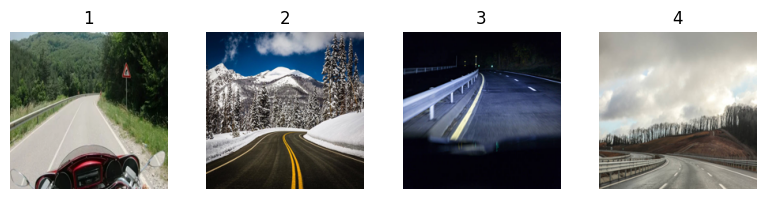

Invalid input. Please enter a valid number.
Please enter a number between 1 and 4.
Please enter a number between 1 and 4.


In [2]:
zip_code = weather.get_zip_code()
current_weather = weather.get_weather_info(zip_code)
current_date_time = date_time.get_date_time()


print(f'The current weather for zip code {zip_code} at {current_date_time} is:\n{current_weather}')
print('\nPlease select an image that depicts a plausible situation given the current weather conditions:\n')
image = read_images.read_image_choice()

In [5]:
tasks = [
    llm_calls.describe_conditions(),
    llm_calls.describe_scene(image)
]

inputs = await asyncio.gather(*tasks)
conditions = inputs[0]
scene = inputs[1]

inputs

[ConditionsResponse(traction='grippy', visibility='high', traffic='moderate'),
 SceneResponse(curve_sharpness='smooth right', visible_curve_length='obstructed near the end', oncoming_traffic='present')]

In [6]:
db.update_vector_db()
# db.client.delete_collection('motorcycle_cornering_docs')

context = db.query_vector_db(conditions=conditions, scene=scene)
context

Vector database up-to-date.


'how the bike exits the ‘curve. Traction management is also improved as well as continuing to improve the sightline in ‘order to see futher down the toad. In general, a smoother, straighter path of travel requires less lean angle which allows for more ‘ground clearance and mote traction. Definitely preferred in situations such as imperfect road surface or a rainy day. 1 Be careful of being near or touching the centerline in left turns. When the bike is leaned over visibility however, try to centre your motorcycle in the lane to ensure that your body remains in your lane during the turn. If you go too wide during right-hand turns, you risk getting injured from oncoming traffic.#5 Your Lean is ImportantBe sure that you are never leaning over the dividing line on the road. A wide line allows you to dive in to clip the apex if the turn is sharper than you thought, but staying in the centre of head-on into a vehicle (right hand turn), or ending up in a tree (left hand turn). This can be cau

In [7]:
rec = llm_calls.recommend_approach(inputs[0], inputs[1], context)
rec

RecommendationResponse(entry_speed='just under speed limit', braking='light, increasing if needed', lean_angle='slight', lane_position='middle')

In [22]:
new_row = {
    'traction': conditions.traction,
    'visibility': conditions.visibility,
    'traffic': conditions.traffic,
    'curve_sharpness': scene.curve_sharpness,
    'curve_visibility': scene.visible_curve_length,
    'oncoming_traffic': scene.oncoming_traffic,
    'entry_speed': rec.entry_speed,
    'braking': rec.braking,
    'lean_angle': rec.lean_angle,
    'lane_position': rec.lane_position
}

with open('recommendations.csv', 'a', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=new_row.keys())
    writer.writerow(new_row)

print("Row added to recommendations.csv")

Row added to recommendations.csv
